# A/B Test Analysis: Cookie Cats Level Gate

**Dataset:** [Cookie Cats on Kaggle](https://www.kaggle.com/datasets/mursideyarkin/mobile-games-ab-testing-cookie-cats). Players were randomly assigned to have the first progress gate at **level 30 (control)** or **level 40 (treatment)**.

## 1. Analysis plan (written before looking at results)

| Item | Decision |
|---|---|
| Hypothesis | Moving the gate from level 30 to 40 changes player retention |
| Control / treatment | `gate_30` / `gate_40` |
| Primary metric | 7-day retention (`retention_7`) |
| Secondary metric | 1-day retention (`retention_1`) |
| Guardrail metric | Game rounds played in first 14 days (`sum_gamerounds`) |
| Significance level | α = 0.05, two-sided |
| Power | 0.80 |
| Minimum detectable effect | 1 percentage point on 7-day retention |
| Decision rule | Ship gate_40 only if the primary metric improves significantly **and** the guardrail does not significantly worsen |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from statsmodels.stats.proportion import (
    proportions_ztest, confint_proportions_2indep, proportion_effectsize
)
from statsmodels.stats.power import NormalIndPower
import duckdb

RNG = np.random.default_rng(42)
ALPHA, POWER, MDE = 0.05, 0.80, 0.01
CONTROL, TREATMENT = "gate_30", "gate_40"
FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

## 2. Load and inspect the data

In [2]:
df = pd.read_csv("cookie_cats.csv")
print(df.shape)
print(df.dtypes)
print("\nMissing values:\n", df.isna().sum())
print("\nDuplicate user IDs:", df["userid"].duplicated().sum())
df.head()

(90189, 5)
userid             int64
version           object
sum_gamerounds     int64
retention_1         bool
retention_7         bool
dtype: object

Missing values:
 userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64

Duplicate user IDs: 0


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


### 2.1 Metrics in SQL
Metrics are calculated in SQL, mirroring how they would be pulled from a data warehouse in practice. Python is then used for the statistical tests.

In [3]:
con = duckdb.connect()
con.register("players", df)  # makes the DataFrame queryable as a SQL table

group_stats = con.execute("""
    SELECT
        version,
        COUNT(*)                                   AS n_users,
        COUNT(DISTINCT userid)                     AS n_unique_users,
        SUM(CAST(retention_1 AS INTEGER))          AS retained_1,
        SUM(CAST(retention_7 AS INTEGER))          AS retained_7,
        ROUND(AVG(CAST(retention_1 AS DOUBLE)), 4) AS retention_1_rate,
        ROUND(AVG(CAST(retention_7 AS DOUBLE)), 4) AS retention_7_rate,
        MEDIAN(sum_gamerounds)                     AS median_rounds,
        ROUND(AVG(sum_gamerounds), 2)              AS mean_rounds
    FROM players
    GROUP BY version
    ORDER BY version
""").df()
group_stats

,version,n_users,n_unique_users,retained_1,retained_7,retention_1_rate,retention_7_rate,median_rounds,mean_rounds
0,gate_30,44700,44700,20034.0,8502.0,0.4482,0.1902,17.0,52.46
1,gate_40,45489,45489,20119.0,8279.0,0.4423,0.1820,16.0,51.30


In [4]:
srm_table = con.execute("""
    SELECT
        version,
        COUNT(*) AS n_users,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS pct_of_total
    FROM players
    GROUP BY version
    ORDER BY version
""").df()
srm_table

,version,n_users,pct_of_total
0,gate_30,44700,49.56
1,gate_40,45489,50.44


In [5]:
outliers = con.execute("""
    WITH cap AS (
        SELECT QUANTILE_CONT(sum_gamerounds, 0.999) AS p999
        FROM players
    )
    SELECT p.userid, p.version, p.sum_gamerounds
    FROM players p, cap
    WHERE p.sum_gamerounds > cap.p999 * 10
    ORDER BY p.sum_gamerounds DESC
""").df()
outliers

,userid,version,sum_gamerounds
0,6390605,gate_30,49854


## 3. Power analysis and sample sizing

The baseline is the control group's 7-day retention. Ideally this would come from pre-experiment data; using the control group is a standard proxy for a public dataset.

Baseline 7-day retention: 19.02%
Required users per group for a 1%pt MDE: 24,658
Smallest actual group size: 44,700
Adequately powered
Achieved power at 1%pt MDE: 96.5%


,MDE (pp),n per group
0,0.50,97679
1,0.75,43625
2,1.00,24658
3,1.25,15856
4,1.50,11063
5,1.75,8166
6,2.00,6281
7,2.25,4985
8,2.50,4056
9,2.75,3367


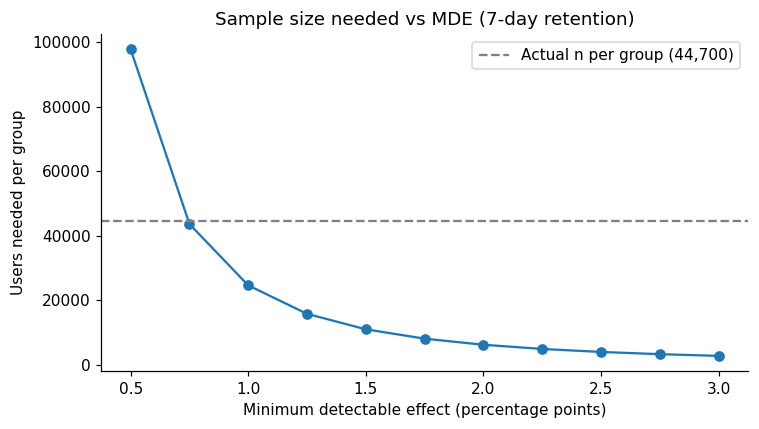

In [6]:
baseline = df.loc[df["version"] == CONTROL, "retention_7"].mean()
power_calc = NormalIndPower()

def required_n(baseline, mde, alpha=ALPHA, power=POWER):
    h = abs(proportion_effectsize(baseline + mde, baseline))
    return int(np.ceil(power_calc.solve_power(effect_size=h, alpha=alpha, power=power, ratio=1)))

n_needed = required_n(baseline, MDE)
n_actual = df["version"].value_counts().min()
print(f"Baseline 7-day retention: {baseline:.2%}")
print(f"Required users per group for a {MDE:.0%}pt MDE: {n_needed:,}")
print(f"Smallest actual group size: {n_actual:,}")
print("Adequately powered" if n_actual >= n_needed else "UNDERPOWERED for this MDE")

# Achieved power for the planned MDE at the actual sample size
h = abs(proportion_effectsize(baseline + MDE, baseline))
achieved = power_calc.power(effect_size=h, nobs1=n_actual, alpha=ALPHA, ratio=1)
print(f"Achieved power at {MDE:.0%}pt MDE: {achieved:.1%}")

# Required sample size across a range of MDEs
mdes = np.arange(0.005, 0.0301, 0.0025)
ns = [required_n(baseline, m) for m in mdes]
power_table = pd.DataFrame({"MDE (pp)": mdes * 100, "n per group": ns})
display(power_table)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(mdes * 100, ns, marker="o")
ax.axhline(n_actual, ls="--", c="grey", label=f"Actual n per group ({n_actual:,})")
ax.set(xlabel="Minimum detectable effect (percentage points)", ylabel="Users needed per group",
       title="Sample size needed vs MDE (7-day retention)")
ax.legend(); plt.tight_layout(); plt.savefig(FIG_DIR / "power_curve.png"); plt.show()

## 4. Data quality checks

### 4.1 Sample ratio mismatch (SRM)
If randomisation worked, group sizes should be close to 50/50. A very small p-value (commonly < 0.01) suggests something went wrong with assignment.

In [7]:
chi2, srm_p = stats.chisquare(srm_table["n_users"])  # expected split: 50/50
print(srm_table)
print(f"\nSRM chi-square = {chi2:.2f}, p = {srm_p:.4f}")
if srm_p < 0.01:
    print("Possible SRM: investigate before trusting results.")
else:
    print("No strong evidence of SRM.")

   version  n_users  pct_of_total
0  gate_30    44700         49.56
1  gate_40    45489         50.44

SRM chi-square = 6.90, p = 0.0086
Possible SRM: investigate before trusting results.


**Result:** the split is 49.56% / 50.44% (44,700 vs 45,489 players), and the chi-square test gives p = 0.0086, below the 0.01 threshold. This is a mild sample ratio mismatch: the imbalance is under 1 percentage point, but it is larger than random assignment would usually produce.

**How I handle it:** the dataset contains no assignment logs, so the cause can't be investigated here. In a real company, I would check the assignment and logging pipeline before trusting the results. Because the imbalance is small and the retention effect is large relative to its uncertainty, I proceed but report this as a key limitation.

### 4.2 Outliers in game rounds

count    90189.000000
mean        51.872457
std        195.050858
min          0.000000
50%         16.000000
90%        134.000000
99%        493.000000
99.9%     1073.624000
max      49854.000000
Name: sum_gamerounds, dtype: float64

Top 5 values: [49854, 2961, 2640, 2438, 2294]


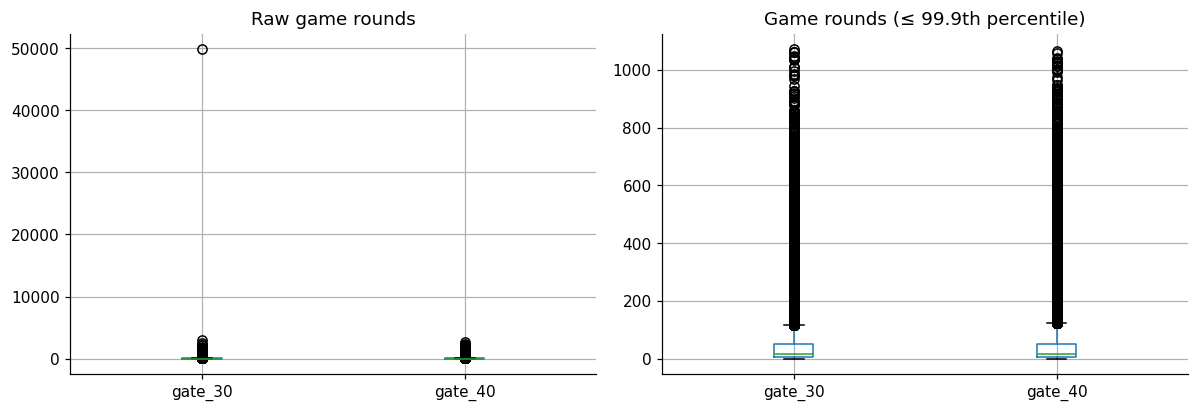

In [8]:
print(df["sum_gamerounds"].describe(percentiles=[.5, .9, .99, .999]))
print("\nTop 5 values:", df["sum_gamerounds"].nlargest(5).tolist())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df.boxplot(column="sum_gamerounds", by="version", ax=axes[0])
axes[0].set(title="Raw game rounds", xlabel="")
cap = df["sum_gamerounds"].quantile(0.999)
df[df["sum_gamerounds"] <= cap].boxplot(column="sum_gamerounds", by="version", ax=axes[1])
axes[1].set(title="Game rounds (≤ 99.9th percentile)", xlabel="")
plt.suptitle(""); plt.tight_layout(); plt.savefig(FIG_DIR / "gamerounds_outliers.png"); plt.show()

**Decision:** game rounds are heavily right-skewed with at least one extreme value. For the guardrail I use a Mann-Whitney U test on the raw data (rank-based, so robust to outliers) and a bootstrap of the mean on data winsorised at the 99.9th percentile. Retention metrics are binary, so they are unaffected.

## 5. Significance testing: primary and secondary metrics

In [9]:
def test_proportions(df, metric):
    g = df.groupby("version")[metric].agg(["sum", "count"]).reindex([CONTROL, TREATMENT])
    xc, nc = g.loc[CONTROL]; xt, nt = g.loc[TREATMENT]
    pc, pt = xc / nc, xt / nt
    z, p = proportions_ztest([xt, xc], [nt, nc])
    lo, hi = confint_proportions_2indep(xt, nt, xc, nc, method="wald", compare="diff", alpha=ALPHA)
    return {
        "metric": metric, "control": pc, "treatment": pt,
        "abs_diff_pp": (pt - pc) * 100, "ci_low_pp": lo * 100, "ci_high_pp": hi * 100,
        "rel_lift_%": (pt / pc - 1) * 100, "z": z, "p_value": p,
    }

results = pd.DataFrame([test_proportions(df, m) for m in ["retention_7", "retention_1"]])

# Bonferroni correction across the two retention metrics
results["p_bonferroni"] = np.minimum(results["p_value"] * len(results), 1)
results["significant"] = results["p_bonferroni"] < ALPHA
results.round(4)

,metric,control,treatment,abs_diff_pp,ci_low_pp,ci_high_pp,rel_lift_%,z,p_value,p_bonferroni,significant
0,retention_7,0.1902,0.1820,-0.8201,-1.3282,-0.3121,-4.3119,-3.1644,0.0016,0.0031,True
1,retention_1,0.4482,0.4423,-0.5905,-1.2392,0.0582,-1.3176,-1.7841,0.0744,0.1488,False


The primary metric (7-day retention) drives the decision. The Bonferroni-adjusted p-values are shown as a robustness check for the secondary metric.

### 5.1 Bootstrap of the retention differences

retention_7: 95% bootstrap CI [-1.34, -0.31]pp, P(gate_40 worse) = 99.9%
retention_1: 95% bootstrap CI [-1.25, 0.07]pp, P(gate_40 worse) = 96.3%


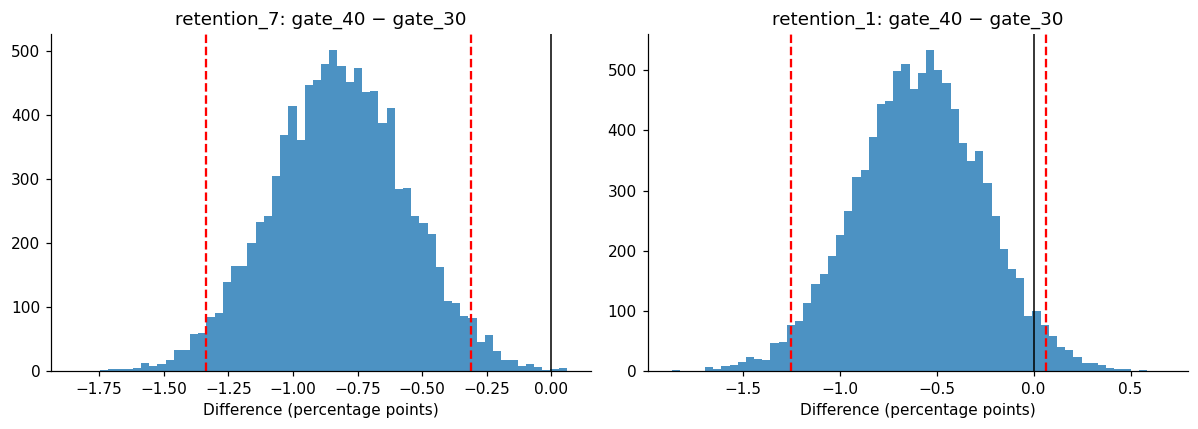

In [10]:
B = 10_000

def bootstrap_prop_diff(df, metric, B=B):
    # For a binary metric, resampling n users with replacement is equivalent to Binomial(n, p_hat) / n
    out = {}
    for v in [CONTROL, TREATMENT]:
        s = df.loc[df["version"] == v, metric]
        out[v] = RNG.binomial(len(s), s.mean(), size=B) / len(s)
    return out[TREATMENT] - out[CONTROL]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, metric in zip(axes, ["retention_7", "retention_1"]):
    diffs = bootstrap_prop_diff(df, metric) * 100
    lo, hi = np.percentile(diffs, [2.5, 97.5])
    prob_worse = (diffs < 0).mean()
    ax.hist(diffs, bins=60, alpha=0.8)
    ax.axvline(0, c="black", lw=1)
    ax.axvline(lo, ls="--", c="red"); ax.axvline(hi, ls="--", c="red")
    ax.set(title=f"{metric}: gate_40 − gate_30", xlabel="Difference (percentage points)")
    print(f"{metric}: 95% bootstrap CI [{lo:.2f}, {hi:.2f}]pp, P(gate_40 worse) = {prob_worse:.1%}")
plt.tight_layout(); plt.savefig(FIG_DIR / "bootstrap_retention.png"); plt.show()

## 6. Guardrail metric: game rounds played

In [11]:
ctrl = df.loc[df["version"] == CONTROL, "sum_gamerounds"]
trt = df.loc[df["version"] == TREATMENT, "sum_gamerounds"]

u, mw_p = stats.mannwhitneyu(trt, ctrl, alternative="two-sided")
print(f"Median rounds: control {ctrl.median():.0f}, treatment {trt.median():.0f}")
print(f"Mann-Whitney U p-value: {mw_p:.4f}")

# Bootstrap the difference in means on winsorised data
cap = df["sum_gamerounds"].quantile(0.999)
ctrl_w, trt_w = ctrl.clip(upper=cap).to_numpy(), trt.clip(upper=cap).to_numpy()
B_mean = 2_000
mean_diffs = np.array([
    RNG.choice(trt_w, len(trt_w)).mean() - RNG.choice(ctrl_w, len(ctrl_w)).mean()
    for _ in range(B_mean)
])
g_lo, g_hi = np.percentile(mean_diffs, [2.5, 97.5])
print(f"Mean rounds (winsorised): control {ctrl_w.mean():.1f}, treatment {trt_w.mean():.1f}")
print(f"Difference in means: {trt_w.mean() - ctrl_w.mean():.2f}, 95% bootstrap CI [{g_lo:.2f}, {g_hi:.2f}]")
guardrail_breached = (mw_p < ALPHA) and (trt.median() < ctrl.median() or g_hi < 0)
print("Guardrail breached" if guardrail_breached else "Guardrail not breached")

Median rounds: control 17, treatment 16
Mann-Whitney U p-value: 0.0502
Mean rounds (winsorised): control 51.0, treatment 50.9
Difference in means: -0.10, 95% bootstrap CI [-1.30, 1.23]
Guardrail not breached


**Result:** the guardrail is not breached. The median dropped from 17 to 16 rounds, but the Mann-Whitney test is borderline (p = 0.0502) and the difference in winsorised means is close to zero, with a confidence interval spanning zero. Engagement looks broadly unchanged, so the decision rests on the primary metric.

## 7. Summary

In [12]:
primary = results.set_index("metric").loc["retention_7"]
secondary = results.set_index("metric").loc["retention_1"]

summary = pd.DataFrame({
    "Metric": ["7-day retention (primary)", "1-day retention (secondary)", "Game rounds (guardrail)"],
    "gate_30": [f"{primary.control:.2%}", f"{secondary.control:.2%}", f"median {ctrl.median():.0f}"],
    "gate_40": [f"{primary.treatment:.2%}", f"{secondary.treatment:.2%}", f"median {trt.median():.0f}"],
    "Difference": [f"{primary.abs_diff_pp:+.2f}pp [{primary.ci_low_pp:.2f}, {primary.ci_high_pp:.2f}]",
                   f"{secondary.abs_diff_pp:+.2f}pp [{secondary.ci_low_pp:.2f}, {secondary.ci_high_pp:.2f}]",
                   f"mean {trt_w.mean() - ctrl_w.mean():+.2f} [{g_lo:.2f}, {g_hi:.2f}]"],
    "p-value": [f"{primary.p_value:.4f}", f"{secondary.p_value:.4f} (adj {secondary.p_bonferroni:.4f})",
                f"{mw_p:.4f} (Mann-Whitney)"],
})
display(summary)

ship = (primary.abs_diff_pp > 0) and (primary.p_value < ALPHA) and not guardrail_breached
harm = (primary.abs_diff_pp < 0) and (primary.p_value < ALPHA)
if ship:
    decision = "SHIP gate_40"
elif harm:
    decision = "DO NOT SHIP: keep the gate at level 30 (gate_40 significantly reduces 7-day retention)"
else:
    decision = "NO CLEAR WINNER: keep gate_30 and consider a retest"
print("Decision under the pre-set rule:", decision)

,Metric,gate_30,gate_40,Difference,p-value
0,7-day retention (primary),19.02%,18.20%,"-0.82pp [-1.33, -0.31]",0.0016
1,1-day retention (secondary),44.82%,44.23%,"-0.59pp [-1.24, 0.06]",0.0744 (adj 0.1488)
2,Game rounds (guardrail),median 17,median 16,"mean -0.10 [-1.30, 1.23]",0.0502 (Mann-Whitney)


Decision under the pre-set rule: DO NOT SHIP: keep the gate at level 30 (gate_40 significantly reduces 7-day retention)


## 8. Product recommendation

**Recommendation: do not ship the level-40 gate. Keep the first gate at level 30.**

**What we found:** moving the gate to level 40 reduced 7-day retention from 19.02% to 18.20%, a drop of 0.82 percentage points (4.3% relative), with a 95% confidence interval of −1.33 to −0.31pp and p = 0.0016. This stays significant after Bonferroni correction, and 99.9% of bootstrap samples show gate_40 performing worse. 1-day retention also fell, by 0.59pp, but this was not statistically significant (p = 0.074). Engagement, measured by game rounds played, showed no meaningful change.

**Why it matters:** 7-day retention is the stronger signal of long-term engagement and revenue. For every 100,000 new players, gate_40 would mean roughly 820 fewer players still active after a week. A likely explanation is that an earlier gate gives players a natural break, which makes them more likely to return.

**Risks and limitations:**
- There is a mild sample ratio mismatch (p = 0.0086). The imbalance is small, but in practice I would check the assignment pipeline before acting.
- The power analysis baseline came from the control group rather than pre-experiment data. The test still had about 96% power to detect a 1pp change.
- Retention is only measured at days 1 and 7; longer-term retention and revenue effects are unknown.
- The one extreme player (49,854 rounds) was handled with rank-based tests and winsorising rather than removed.

**Next steps:** test other gate positions (for example level 25 or 35) to find the best placement, measure the effect on in-app purchases, and look at whether the effect differs between casual and highly engaged players.

## 9. Applying this framework at Monzo (hypothetical case study)

To show how this approach would transfer to a bank, here is a design for a plausible Monzo experiment. All baseline figures are assumptions for illustration, not Monzo data.

### The idea
New customers often don't discover Savings Pots. **Hypothesis:** showing new customers a prompt to open a pot after their first salary payment arrives will increase pot adoption.

### Design
- **Unit of randomisation:** customer (not session), so each person sees a consistent experience.
- **Population:** new customers who receive their first salary-like payment during the test window.
- **Split:** 50/50 between control (no prompt) and treatment (prompt).
- **Duration:** whole weeks only, to avoid day-of-week effects, and long enough to get past any novelty effect.

### Metrics
| Type | Metric | Why |
|---|---|---|
| Primary | % of customers who open a pot within 30 days | Directly measures the behaviour we want to change |
| Secondary | Average amount saved into pots at 30 days | Shows whether adoption leads to real saving |
| Guardrail | Declined card payments due to insufficient funds | Moving money into pots could leave customers short for bills, which is real financial harm |
| Guardrail | Customer support contacts and complaints | Detects confusion or frustration caused by the prompt |
| Guardrail | Account closures within 30 days | Detects customers being put off entirely |

### Banking-specific considerations
- **Customer harm matters more than in most products.** Under the FCA's Consumer Duty, firms must deliver good outcomes for retail customers. So a guardrail like declined payments should block a launch even if the primary metric improves.
- **Vulnerable customers.** I'd check the results separately for customers showing signs of financial difficulty, and consider excluding them from the test.
- **Long-term effects.** 30-day pot adoption might not translate into lasting saving habits, so I'd keep a small holdout group without the prompt to measure the effect over several months.

### Decision rule (set before launch)
Ship the prompt if pot adoption increases significantly **and** no guardrail metric worsens significantly. If adoption rises but declined payments also rise, don't ship; redesign the prompt instead (for example, suggest a smaller amount).

In [13]:
# Power analysis for the hypothetical Monzo experiment
ASSUMED_BASELINE = 0.25  # assumption: 25% of new customers open a pot within 30 days

print(f"Assumed baseline pot adoption: {ASSUMED_BASELINE:.0%}\n")
for mde in [0.01, 0.02, 0.03]:
    n = required_n(ASSUMED_BASELINE, mde)
    print(f"To detect a {mde*100:.0f}pp increase: {n:,} customers per group")

Assumed baseline pot adoption: 25%

To detect a 1pp increase: 29,820 customers per group
To detect a 2pp increase: 7,549 customers per group
To detect a 3pp increase: 3,395 customers per group
